# Multi-frequency MIDAS (weekly target, daily + monthly predictors)

MIDAS is the mixed-frequency counterpart to the weekly ARIMAX / VAR / tree notebooks. The target is
the weekly W-FRI silver log-return, but genuinely daily predictors enter at their native frequency:
cross-asset returns, GS, FRED-rate changes, and forward-filled sentiment ablations each use K=20
trading-day lag paths. In the main MIDAS specification, monthly macro variables also enter through
publication-lagged restricted MIDAS blocks. As a small robustness check, `Macro_UMIDAS` ablations
relax only the monthly macro block by keeping its K=3 lags as separate OLS regressors; this is feasible
because the monthly block is small, unlike the daily block.
Only weekly-release variables (jobless + COT) remain one-week-lagged scalar controls. The notebook
uses restricted Beta / exp-Almon weights, then runs the same Drift-floor, RMSE/WDA, DM/PT, and ex-2025
evaluation battery as the other weekly models.

### Roadmap

| § | Step | What happens |
|---|---|---|
| 0 | Model intuition | The multi-frequency MIDAS setup: a weekly target driven by *two* higher frequencies — daily cross-asset/HF blocks (K=20 trading-day lags) and monthly macro — each collapsed by a lag-weight curve. |
| 1 | Load + aggregate | Read the daily train/val/test frames; build the weekly W-FRI target and align everything to it. |
| 2 | Base + weekly controls | Silver weekly AR lags + optional weekly-release scalar controls (`Jobless`, `COT`). |
| 3 | Daily HF blocks | K=20 trading-day lag matrices — daily cross-asset returns (always on) + optional GS / FRED-change / sentiment HF ablations — with a look-ahead audit. |
| 4 | Monthly macro block | The second frequency: publication-availability-lagged monthly macro (`cpi, fed_funds, ind_prod, m2`) as restricted MIDAS (or `Macro_UMIDAS` = free OLS lags) + a look-ahead audit. |
| 5 | Sentiment carry-forward | Check the daily-sentiment forward-fill before it enters the HF block. |
| 6 | MIDAS weights + fitters | Beta / exp-Almon weight curves and the NLS fitter, generic over the list of daily + monthly lag matrices. |
| 7 | Two-stage protocol | **Stage 1**: pick the weight family on validation. **Stage 2**: freeze it, walk forward (expanding + rolling-100w, refit every 4w) over the ablation ladder. |
| 8 | Results table | RMSE / MAE / OOS R² / DA / WDA for Naive, Drift, and every MIDAS rung. Save `metrics_midas_daily_weekly.csv`. |
| 9 | Period breakdown | Drift floor + WDA-best + RMSE-best per `PERIODS`; save period + preds CSVs. |
| 10 | Significance tests | Load-bearing DM vs-Drift floor (OOS R² + DM, squared & absolute error); Pesaran–Timmermann directional lens. |
| 11 | Robustness — ex-2025 | Re-run the battery on 2023 + 2024 + 2026 only. |
| 12 | 2026 zoom | WDA-best and RMSE-best vs the drift floor on the 2026 YTD slice. |
| 13 | Lag-weight profiles | The MIDAS analogue of feature importance — the fitted lag-weight curve per daily / monthly block. |

## 0. Model intuition

Let $y_t$ be the weekly silver return for forecast week $t$. A standard weekly regression would first
collapse a daily predictor into one weekly number. MIDAS keeps the recent daily path and learns how
much each high-frequency lag should matter.

For a daily predictor $x_j$, construct the public-information lag vector available before week $t$:

$$
\mathbf x_{j,t}^{(d)} =
\begin{bmatrix}
x_{j,t-1}^{(d)} & x_{j,t-2}^{(d)} & \cdots & x_{j,t-K}^{(d)}
\end{bmatrix}',
\qquad K=20.
$$

Restricted MIDAS replaces those $K$ separate coefficients with a normalized lag-weight curve:

$$
m_{j,t}(\theta_j) = \sum_{k=1}^{K} w_j(k;\theta_j) x_{j,t-k}^{(d)},
\qquad \sum_{k=1}^{K} w_j(k;\theta_j)=1.
$$

The forecast equation is therefore a weekly silver regression with compressed daily and monthly
histories:

$$
y_t = \alpha
+ \sum_{i=1}^{p}\phi_i y_{t-i}
+ \sum_j \beta_j m_{j,t}^{(d)}(\theta_j)
+ \sum_m \delta_m m_{m,t}^{(M)}(\eta_m)
+ \sum_q \gamma_q q_{q,t-1}
+ \varepsilon_t.
$$

Here $m_{j,t}^{(d)}$ are daily MIDAS blocks, $m_{m,t}^{(M)}$ are publication-lagged monthly macro
blocks, and $q_{q,t-1}$ are weekly-release controls such as jobless claims and COT. The main model keeps
both daily and monthly mixed-frequency blocks restricted. The `Macro_UMIDAS` ablations are narrower:
they keep daily predictors restricted, but replace the monthly macro term with separate coefficients for
each monthly lag. That is only considered because the monthly block has K=3 lags per variable, so the
unrestricted version adds 12 columns rather than hundreds. The key idea is parsimony: instead of
estimating 20 separate daily coefficients per variable, Beta or exp-Almon
weights estimate a smooth lag profile. That is what makes daily information usable in a weekly
forecast without turning the regression into an overfit kitchen sink.


## Setup


*Imports the numerical stack, plotting tools, and shared evaluation helpers.*


In [1]:
import sys, os
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
sys.path.append('../../../../src')
from eval_utils import evaluate, period_metrics, diebold_mariano, pesaran_timmermann, oos_r2, PERIODS

DATA = '../../../../data/processed/'
RAW  = '../../../../data/raw/'


## 1. Load & aggregate to weekly


*Loads the train/val/test splits and builds the W-FRI target frame. The notebook uses daily predictor lags, but the forecast target and evaluation grid are weekly, so `to_weekly()` is still needed for `silver_return`, split lengths, and weekly scalar controls.*


In [2]:
train = pd.read_csv(DATA+'train.csv', index_col=0, parse_dates=True)
val   = pd.read_csv(DATA+'val.csv',   index_col=0, parse_dates=True)
test  = pd.read_csv(DATA+'test.csv',  index_col=0, parse_dates=True)

TARGET              = 'silver_return'
CROSS_ASSET_HF_VARS = ['gold_return','usd_return','copper_return','sp500_return','vix_return','oil_return']
GS_HF_VARS          = ['gs_ratio_z']
FRED_HF_VARS        = ['real_rates_chg','breakeven_chg']
FRED_WEEKLY_CHG_VARS = ['jobless_chg']
COT_STATE_VARS      = ['cot_mm_net_pct','cot_comm_net_pct']

# This weekly frame is only the target/evaluation skeleton plus true weekly-release controls.
# Daily HF predictors are intentionally not aggregated here; they stay in `daily` below and
# become K_DAILY-lag MIDAS matrices.
def to_weekly(df):
    # Returns and log-change variables add over time. `jobless_chg` is already
    # log(jobless_claims).diff(), so summing the mostly-zero daily values recovers
    # the weekly claims change. If we modeled raw jobless_claims levels, that would
    # belong in `last` instead.
    summ = [c for c in [TARGET] + FRED_WEEKLY_CHG_VARS if c in df.columns]
    # COT net-positioning ratios are weekly state variables forward-filled onto the daily grid.
    # Use the latest snapshot in the W-FRI bucket; the 1-week lag below handles Friday publication timing.
    last = [c for c in COT_STATE_VARS if c in df.columns]
    agg = {c: 'sum' for c in summ}
    agg.update({c: 'last' for c in last})
    return df.resample('W-FRI').agg(agg)

# Keep train/val/test weekly lengths separate for the later walk-forward split points.
train_w, val_w, test_w = to_weekly(train), to_weekly(val), to_weekly(test)
all_weekly   = pd.concat([train_w, val_w, test_w]).sort_index()
n_train = len(train_w) + len(val_w)
print(f'Weekly obs — train+val: {n_train}, test: {len(test_w)}')


Weekly obs — train+val: 417, test: 174


## 2. Base (silver AR) + weekly-release controls


*Builds weekly silver AR terms plus one-week-lagged jobless and COT controls.*


In [3]:
for k in (1,2,3):
    all_weekly[f'silver_lag{k}'] = all_weekly['silver_return'].shift(k)
# Jobless claims and COT are released weekly, so they remain weekly public-information controls.
for v in FRED_WEEKLY_CHG_VARS + COT_STATE_VARS:
    if v in all_weekly.columns:
        all_weekly[f'{v}_lag1'] = all_weekly[v].shift(1).fillna(0.0)

AR_LAGS   = [c for c in ['silver_lag1','silver_lag2','silver_lag3'] if c in all_weekly.columns]
JOBLESS_LAGS = [f'{v}_lag1' for v in FRED_WEEKLY_CHG_VARS if f'{v}_lag1' in all_weekly.columns]
COT_LAGS  = [f'{v}_lag1' for v in COT_STATE_VARS if f'{v}_lag1' in all_weekly.columns]
print('AR:', AR_LAGS, '| Jobless:', JOBLESS_LAGS, '| COT:', COT_LAGS)


AR: ['silver_lag1', 'silver_lag2', 'silver_lag3'] | Jobless: ['jobless_chg_lag1'] | COT: ['cot_mm_net_pct_lag1', 'cot_comm_net_pct_lag1']


## 3. Daily high-frequency blocks


*Constructs high-frequency daily lag matrices: cross-assets, GS, FRED-rate changes, and forward-filled sentiment blocks for ablations.*


In [4]:
# Raw train/val/test are daily frames. We concatenate them only to build lag matrices;
# the weekly train/val/test boundaries still come from train_w / val_w / test_w above.
daily = pd.concat([train, val, test]).sort_index()

# Sentiment is sparse. Forward-fill means: on each trading day, use the latest known
# sentiment score rather than treating non-news days as zero sentiment.
SENT_HF_VARS = ['reddit_sentiment','news_sentiment']
assert all(v in daily.columns for v in CROSS_ASSET_HF_VARS + GS_HF_VARS + FRED_HF_VARS + SENT_HF_VARS)
daily_hf = daily.copy()
daily_hf[SENT_HF_VARS] = daily_hf[SENT_HF_VARS].ffill()

# Number of daily observations fed into each MIDAS block: roughly one trading month.
K_DAILY = 20

def build_daily_midas_matrix(weekly_dates, daily_series, n_lags):
    """
    Build one daily-to-weekly MIDAS lag matrix.

    Why this exists:
      The target is weekly, but these predictors are daily. For each weekly target
      row, MIDAS needs a fixed-length row containing the most recent daily values
      that were available before that forecast week began.

    Inputs:
      weekly_dates : Friday labels for weekly silver-return targets.
      daily_series : one daily predictor, indexed by daily/trading dates.
      n_lags       : number of daily observations to keep per weekly row.

    Output:
      A matrix with shape (n_weeks, n_lags). For each weekly row:
        column 0          = newest allowed daily observation
        column n_lags - 1 = oldest observation in the daily window

    Warm-up rows stay NaN until enough daily history exists; later finite-row masks
    drop those rows only for variants that need them.
    """
    values = daily_series.to_numpy()
    observed = ~np.isnan(values)
    lag_matrix = np.full((len(weekly_dates), n_lags), np.nan)

    for row, week_end in enumerate(weekly_dates):
        # A W-FRI target week is labelled by its Friday. To avoid look-ahead, the
        # forecast can only use data available before that week starts. Friday - 6
        # days is the preceding Saturday, so '< cutoff' allows the previous Friday
        # and earlier, but excludes the target week's Monday-Friday observations.
        public_info_cutoff = week_end - pd.Timedelta(days=6)

        usable_history = observed & (daily_series.index < public_info_cutoff)
        usable_values = values[usable_history]

        if len(usable_values) >= n_lags:
            newest_last = usable_values[-n_lags:]
            lag_matrix[row] = newest_last[::-1]  # lag_01 first, lag_n last

    return lag_matrix

# Each dictionary maps a readable MIDAS-series name to a weekly x K_DAILY matrix.
# The estimator later learns one restricted Beta/Almon weight curve per matrix.

# 1) Cross-asset daily returns: the canonical high-frequency EXOG block.
daily_lags = {}
for var in CROSS_ASSET_HF_VARS:
    midas_name = var.replace('_return', '')
    daily_lags[midas_name] = build_daily_midas_matrix(all_weekly.index, daily[var], K_DAILY)

# 2) GS ratio: a daily level/z-score, kept daily rather than collapsed weekly.
gs_hf_lags = {}
gs_hf_lags['gs_ratio_hf'] = build_daily_midas_matrix(all_weekly.index, daily['gs_ratio_z'], K_DAILY)

# 3) FRED market-rate changes: genuinely daily changes. Weekly jobless_chg is not
# here; it is a weekly-release control handled in to_weekly() above.
fred_hf_lags = {}
for var in FRED_HF_VARS:
    midas_name = f'{var.replace("_chg", "")}_hf'
    fred_hf_lags[midas_name] = build_daily_midas_matrix(all_weekly.index, daily[var], K_DAILY)

# 4) Sentiment: use daily_hf, where sparse sentiment is forward-filled to the
# latest known tone before building the lag path.
sent_hf_lags = {}
for var in SENT_HF_VARS:
    midas_name = var.replace('_sentiment', '_sent_hf')
    sent_hf_lags[midas_name] = build_daily_midas_matrix(all_weekly.index, daily_hf[var], K_DAILY)

# Paid-news (title) daily-MIDAS block — paid twin of news_sent_hf (reddit kept as-is). The splits now
# carry news_paid_sentiment_title (02_features daily sentiment join); forward-fill like other sentiment.
daily_hf['news_paid_sentiment_title'] = daily['news_paid_sentiment_title'].ffill()
news_paid_sent_hf = build_daily_midas_matrix(all_weekly.index, daily_hf['news_paid_sentiment_title'], K_DAILY)
sent_paid_hf_lags = {'reddit_sent_hf': sent_hf_lags['reddit_sent_hf'], 'news_paid_sent_hf': news_paid_sent_hf}

print('Daily lag matrices:', {
    'cross_asset_hf': {v: m.shape for v, m in daily_lags.items()},
    'gs_hf': {v: m.shape for v, m in gs_hf_lags.items()},
    'fred_hf': {v: m.shape for v, m in fred_hf_lags.items()},
    'sent_hf_ffill': {v: m.shape for v, m in sent_hf_lags.items()},
})


Daily lag matrices: {'cross_asset_hf': {'gold': (591, 20), 'usd': (591, 20), 'copper': (591, 20), 'sp500': (591, 20), 'vix': (591, 20), 'oil': (591, 20)}, 'gs_hf': {'gs_ratio_hf': (591, 20)}, 'fred_hf': {'real_rates_hf': (591, 20), 'breakeven_hf': (591, 20)}, 'sent_hf_ffill': {'reddit_sent_hf': (591, 20), 'news_sent_hf': (591, 20)}}


### Look-ahead audit — daily block


*Audits that each high-frequency daily lag matrix only uses information available before the forecast week.*


In [5]:
position_fri = all_weekly.index - pd.Timedelta(days=7)
HF_LABELS = {'gs_ratio_z': 'gs_ratio_hf'}
for v in CROSS_ASSET_HF_VARS + GS_HF_VARS + FRED_HF_VARS + SENT_HF_VARS:
    s = daily_hf[v] if v in SENT_HF_VARS else daily[v]
    obs = s.notna().values; min_slack = np.inf
    for i, d in enumerate(all_weekly.index):
        keep = obs & (s.index < d - pd.Timedelta(days=6))
        if keep.any():
            min_slack = min(min_slack, (position_fri[i] - s.index[keep].max()).days)
    assert not (np.isfinite(min_slack) and min_slack < 0), f'look-ahead in daily {v}'
    label = HF_LABELS.get(v, v.replace('_return','').replace('_chg','_hf').replace('_sentiment','_sent_hf'))
    print(f'  {label:16s} OK  (min slack {int(min_slack)} d)')
print('Daily look-ahead audit passed.')


  gold             OK  (min slack 0 d)
  usd              OK  (min slack 0 d)


  copper           OK  (min slack 0 d)
  sp500            OK  (min slack 0 d)
  vix              OK  (min slack 0 d)
  oil              OK  (min slack 0 d)


  gs_ratio_hf      OK  (min slack 0 d)


  real_rates_hf    OK  (min slack 0 d)
  breakeven_hf     OK  (min slack 0 d)
  reddit_sent_hf   OK  (min slack 0 d)


  news_sent_hf     OK  (min slack 0 d)
Daily look-ahead audit passed.


*Prints one concrete MIDAS lag-matrix row so the daily-to-weekly structure is visible.*


In [6]:
# Example: inspect one weekly forecast row from the daily MIDAS matrices.
# This does not fit a model; it just shows the data shape fed into MIDAS.
example_mats = {
    'gold': daily_lags['gold'],
    'gs_ratio_hf': gs_hf_lags['gs_ratio_hf'],
    'real_rates_hf': fred_hf_lags['real_rates_hf'],
    'news_sent_hf': sent_hf_lags['news_sent_hf'],
}

# Prefer a test-week example, but fall back to any fully finite row if needed.
candidate_rows = list(range(n_train, len(all_weekly))) + list(range(len(all_weekly)))
example_i = None
for i in candidate_rows:
    if all(np.isfinite(mat[i]).all() for mat in example_mats.values()):
        example_i = i
        break
if example_i is None:
    raise ValueError('No fully finite daily MIDAS example row found.')

example_week = all_weekly.index[example_i]
example_cutoff = example_week - pd.Timedelta(days=6)

def lag_dates_for_example(s, week_end, k):
    # Recreate the date labels for the lag row. The lag matrices store values only,
    # so this helper shows which daily dates those values came from.
    cutoff = week_end - pd.Timedelta(days=6)
    usable = s.notna().to_numpy() & (s.index < cutoff)
    return s.index[usable][-k:][::-1]

example_dates = lag_dates_for_example(daily['gold_return'], example_week, K_DAILY)
example_table = pd.DataFrame({
    'lag_col': [f'lag_{j:02d}' for j in range(1, K_DAILY + 1)],
    'daily_date_used': [d.date().isoformat() for d in example_dates],
})
for name, mat in example_mats.items():
    example_table[name] = mat[example_i]

print(f'Example weekly target row: {example_week.date()}')
print(f'Public-info cutoff:       {example_cutoff.date()}  (use daily dates strictly before this)')
print('lag_01 is newest available daily observation; lag_20 is oldest in the 20-day window.\n')
print(example_table.round(6).to_string(index=False))


Example weekly target row: 2023-01-06
Public-info cutoff:       2022-12-31  (use daily dates strictly before this)
lag_01 is newest available daily observation; lag_20 is oldest in the 20-day window.

lag_col daily_date_used      gold  gs_ratio_hf  real_rates_hf  news_sent_hf
 lag_01      2022-12-30  0.000110    -0.251667           0.02      0.009219
 lag_02      2022-12-29  0.006396    -0.329586          -0.04      0.009219
 lag_03      2022-12-28 -0.003809    -0.235613           0.02      0.009219
 lag_04      2022-12-27  0.010469    -0.338145           0.03     -0.022724
 lag_05      2022-12-23  0.004968    -0.328980           0.07     -0.022724
 lag_06      2022-12-22 -0.016043    -0.267312           0.07      0.164996
 lag_07      2022-12-21  0.000000    -0.331228          -0.04      0.059916
 lag_08      2022-12-20  0.015651    -0.352047           0.03      0.833052
 lag_09      2022-12-19 -0.001286    -0.097622           0.07      0.154275
 lag_10      2022-12-16  0.007177    -0

## 4. Monthly macro block — the second frequency


*Constructs weekly-aligned monthly MIDAS matrices. The raw macro series are monthly, but the weekly forecaster still needs, for every Friday target row, the most recent publication-available monthly releases.*


In [7]:
macro = pd.read_csv(RAW+'monthly_macro.csv', index_col=0, parse_dates=True)
MACRO_VARS = ['cpi','fed_funds','ind_prod','m2']
assert all(v in macro.columns for v in MACRO_VARS), 'monthly_macro.csv missing a column'

# Quarterly macro memory. A five-release sensitivity was tested and did not improve OOS results.
N_MACRO_LAGS = 3

# These are approximate publication delays from the month stamp to when the value is
# allowed to enter a forecast. They keep the macro block point-in-time enough for this thesis.
MACRO_AVAIL_LAG = {'cpi':46,'ind_prod':48,'fed_funds':35,'m2':30}

def build_monthly_midas_matrix(weekly_dates, monthly_series, release_lag_days, n_lags=N_MACRO_LAGS):
    """
    Build one monthly-to-weekly MIDAS lag matrix.

    Why this exists even though macro data are already monthly:
      The model forecasts weekly silver returns. For each weekly Friday, we need a
      row containing the most recent monthly releases that would have been public
      before that forecast week began. The raw monthly series alone does not answer
      that weekly alignment / publication-timing question.

    Output:
      shape (n_weeks, n_lags), with mlag_1/newest first and mlag_n/oldest last.
    """
    monthly_values = monthly_series.to_numpy()
    observed = ~np.isnan(monthly_values)
    available_dates = monthly_series.index + pd.Timedelta(days=release_lag_days)
    lag_matrix = np.full((len(weekly_dates), n_lags), np.nan)

    for row, week_end in enumerate(weekly_dates):
        public_info_cutoff = week_end - pd.Timedelta(days=6)
        usable_history = observed & (available_dates < public_info_cutoff)
        usable_values = monthly_values[usable_history]

        if len(usable_values) >= n_lags:
            newest_last = usable_values[-n_lags:]
            lag_matrix[row] = newest_last[::-1]

    return lag_matrix

macro_lags = {}
for var in MACRO_VARS:
    macro_lags[var] = build_monthly_midas_matrix(
        all_weekly.index,
        macro[var],
        MACRO_AVAIL_LAG[var],
    )

print('Macro lag matrices:', {v: m.shape for v, m in macro_lags.items()})


Macro lag matrices: {'cpi': (591, 3), 'fed_funds': (591, 3), 'ind_prod': (591, 3), 'm2': (591, 3)}


### Look-ahead audit — macro


*Audits that each monthly macro lag matrix only uses information available before the forecast week.*


In [8]:
position_fri = all_weekly.index - pd.Timedelta(days=7)
for v in MACRO_VARS:
    avail = macro.index + pd.Timedelta(days=MACRO_AVAIL_LAG[v]); obs = macro[v].notna().values
    min_slack = np.inf
    for i, d in enumerate(all_weekly.index):
        keep = obs & (avail < d - pd.Timedelta(days=6))
        if keep.any():
            min_slack = min(min_slack, (position_fri[i] - avail[keep].max()).days)
    assert not (np.isfinite(min_slack) and min_slack < 0), f'look-ahead in {v}'
    print(f'  {v:11s} OK  (min slack {int(min_slack)} d)')
print('Macro look-ahead audit passed.')


  cpi         OK  (min slack 0 d)
  fed_funds   OK  (min slack 0 d)


  ind_prod    OK  (min slack 0 d)
  m2          OK  (min slack 0 d)
Macro look-ahead audit passed.


*Prints one concrete monthly MIDAS lag row so the publication-lagged macro structure is visible.*


In [9]:
# Example: inspect one weekly forecast row from the monthly macro MIDAS matrices.
# This mirrors the daily example above, but shows macro period stamps and availability dates.
macro_candidate_rows = list(range(n_train, len(all_weekly))) + list(range(len(all_weekly)))
macro_example_i = None
for i in macro_candidate_rows:
    if all(np.isfinite(macro_lags[var][i]).all() for var in MACRO_VARS):
        macro_example_i = i
        break
if macro_example_i is None:
    raise ValueError('No fully finite monthly MIDAS example row found.')

macro_example_week = all_weekly.index[macro_example_i]
macro_example_cutoff = macro_example_week - pd.Timedelta(days=6)

macro_rows = []
for var in MACRO_VARS:
    release_lag = MACRO_AVAIL_LAG[var]
    series = macro[var].dropna().sort_index()
    available_dates = series.index + pd.Timedelta(days=release_lag)
    usable = available_dates < macro_example_cutoff

    periods = series.index[usable][-N_MACRO_LAGS:][::-1]
    releases = available_dates[usable][-N_MACRO_LAGS:][::-1]
    values = series.to_numpy()[usable][-N_MACRO_LAGS:][::-1]

    for lag_num, (period, release_date, value) in enumerate(zip(periods, releases, values), start=1):
        macro_rows.append({
            'series': var,
            'mlag': f'mlag_{lag_num}',
            'macro_period': period.date().isoformat(),
            'available_from': release_date.date().isoformat(),
            'value': value,
        })

macro_example = pd.DataFrame(macro_rows)
print(f'Example weekly target row: {macro_example_week.date()}')
print(f'Public-info cutoff:       {macro_example_cutoff.date()}  (macro releases must be before this)')
print('mlag_1 is newest publication-available monthly value; mlag_3 is oldest.\n')
print(macro_example.round(6).to_string(index=False))


Example weekly target row: 2023-01-06
Public-info cutoff:       2022-12-31  (macro releases must be before this)
mlag_1 is newest publication-available monthly value; mlag_3 is oldest.

   series   mlag macro_period available_from      value
      cpi mlag_1   2022-11-01     2022-12-17   298.7860
      cpi mlag_2   2022-10-01     2022-11-16   298.0070
      cpi mlag_3   2022-09-01     2022-10-17   296.3490
fed_funds mlag_1   2022-11-01     2022-12-06     3.7800
fed_funds mlag_2   2022-10-01     2022-11-05     3.0800
fed_funds mlag_3   2022-09-01     2022-10-06     2.5600
 ind_prod mlag_1   2022-11-01     2022-12-19   100.9552
 ind_prod mlag_2   2022-10-01     2022-11-18   101.2529
 ind_prod mlag_3   2022-09-01     2022-10-19   101.2918
       m2 mlag_1   2022-11-01     2022-12-01 21406.5000
       m2 mlag_2   2022-10-01     2022-10-31 21461.5000
       m2 mlag_3   2022-09-01     2022-10-01 21536.5000


## 5. Daily sentiment carry-forward check


*Explains the sentiment forward-fill coverage. `raw_non_null` counts actual observed sentiment rows before filling; `ffill_non_null` counts rows with a usable latest-known sentiment value after carrying observations forward; `first_valid` is the first real observation date.*


In [10]:
sent_coverage = pd.DataFrame({
    'raw_non_null': daily[SENT_HF_VARS].notna().sum(),
    'ffill_non_null': daily_hf[SENT_HF_VARS].notna().sum(),
    'first_valid': [daily[v].first_valid_index() for v in SENT_HF_VARS],
})
print('raw_non_null   = actual observed sentiment values before forward-fill')
print('ffill_non_null = rows with a latest-known sentiment value after forward-fill')
print('first_valid    = first real observed sentiment date; values before this stay missing\n')
print(sent_coverage.to_string())


raw_non_null   = actual observed sentiment values before forward-fill
ffill_non_null = rows with a latest-known sentiment value after forward-fill
first_valid    = first real observed sentiment date; values before this stay missing

                  raw_non_null  ffill_non_null first_valid
reddit_sentiment          2783            2783  2015-03-30
news_sentiment            1587            2150  2017-10-09


## 6. MIDAS weight functions and fitters


*Defines the two restricted lag-weight curves. Both return normalized weights that sum to one, so each raw lag matrix is compressed into one weighted MIDAS feature.*


In [11]:
def nbeta_w(k, theta):
    th = np.maximum(theta, 0.1)
    x  = k / (k.max() + 1)
    w  = x**(th[0]-1) * (1-x)**(th[1]-1)
    w  = np.maximum(w, 1e-10)
    return w / w.sum()

def nealmon_w(k, theta):
    e = theta[0]*k + theta[1]*k**2
    e = e - e.max()
    w = np.exp(e)
    return w / w.sum()


*Builds the restricted MIDAS estimator used throughout the notebook, rather than calling a black-box package. We do this because the notebook needs one transparent estimator that can be reused inside validation and walk-forward ablations, with custom daily/monthly lag matrices, variable-specific Beta/Almon weights, and explicit public-information masks.*

*The key idea is that only the lag-weight shapes are nonlinear. Each MIDAS variable gets its own lag matrix $X_j$ and its own two shape parameters $\theta_j$; for example, gold's 20 daily lags get one weight curve, while CPI's 3 monthly lags get a separate weight curve. The curve compresses many lag columns into one weighted feature $X_j w_j(\theta_j)$. Once those weighted features are formed, the rest is ordinary OLS: estimate the intercept, weekly-control coefficients, and one coefficient per MIDAS feature. The optimizer searches over the variable-specific weight-shape parameters, and OLS solves the linear regression at each trial.*


In [12]:
# Restricted MIDAS only (Beta/Almon). The canonical daily block alone has 6x20=120
# raw daily lag columns. Estimating all of those lag coefficients separately (U-MIDAS)
# would be too flexible for the weekly sample, so each variable's lag block is reduced
# to one weighted feature before the linear regression is estimated.
def fit_with_midas(y, base_X, midas_mats, weight_fn=nbeta_w, start=None, lower=None):
    """
    Fit a restricted MIDAS regression by nonlinear least squares.

    base_X:
      ordinary weekly regressors, such as silver AR lags and weekly controls.
    midas_mats:
      dict of {name -> matrix}; each matrix is n_rows x n_lags. Each matrix is one
      MIDAS variable's lag history, such as 20 daily gold lags or 3 monthly CPI lags.

    The algorithm nests OLS inside a nonlinear optimizer:
      1. Try a candidate theta_j for every MIDAS variable j.
      2. Convert each lag matrix into one weighted column:
           weighted_feature_j = midas_matrix_j @ weights_j(theta_j)
      3. Given those weighted columns, solve the linear regression by OLS.
      4. Score the candidate theta by the OLS residual sum of squares.

    This means the optimizer is not estimating every regression coefficient directly;
    it only searches over the nonlinear lag-weight shapes. OLS handles the intercept,
    weekly-control coefficients, and MIDAS feature coefficients at each trial.
    """
    names = list(midas_mats)
    n_midas = len(names)

    # Lag positions used by the weight functions: 1=newest lag, K=oldest lag.
    lag_numbers = {name: np.arange(1, midas_mats[name].shape[1] + 1) for name in names}

    # Two shape parameters per MIDAS variable. With 10 MIDAS variables, theta has length 20:
    # [var1_shape1, var1_shape2, var2_shape1, var2_shape2, ...]. Beta starts near a
    # recent-lag-heavy curve; Almon starts flatter. Bounds are supplied by the caller
    # because the two weight families have different parameter constraints.
    if start is None:
        start = np.tile([1.0, 5.0], n_midas)
    if lower is None:
        lower = np.full(2 * n_midas, 0.1)

    base = np.asarray(base_X, float)
    y = np.asarray(y, float)

    def design(theta):
        """Build the OLS design matrix implied by one candidate set of MIDAS weights."""
        weighted_cols = []
        for j, name in enumerate(names):
            # Pull this variable's two shape parameters, turn them into K lag weights,
            # then compress the n_rows x K lag matrix into one n_rows vector.
            theta_j = theta[2*j:2*j+2]
            weights_j = weight_fn(lag_numbers[name], theta_j)
            weighted_cols.append(midas_mats[name] @ weights_j)

        # Final regression design: intercept + ordinary weekly regressors + one
        # compressed MIDAS feature per variable.
        return np.column_stack([np.ones(len(y)), base, np.column_stack(weighted_cols)])

    def obj(theta):
        """Objective minimized by L-BFGS-B: OLS residual SSE for candidate theta."""
        X = design(theta)
        if not np.all(np.isfinite(X)):
            return 1e9

        # Conditional on theta, this is just a standard least-squares regression.
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        resid = y - X @ beta
        return float(resid @ resid)

    res = minimize(
        obj,
        start,
        method='L-BFGS-B',
        bounds=[(lo, None) for lo in lower],
        options={'maxiter': 1000},
    )

    # Convert the optimum theta back into readable per-variable lag weights.
    theta = res.x
    weights = {}
    for j, name in enumerate(names):
        weights[name] = weight_fn(lag_numbers[name], theta[2*j:2*j+2])

    # Refit OLS once at the optimum theta and store both pieces of the model:
    # the linear OLS coefficients and the nonlinear MIDAS lag weights.
    X = design(theta)
    coefs, *_ = np.linalg.lstsq(X, y, rcond=None)
    return {
        'spec': 'restricted',
        'weights': weights,
        'coefs': coefs,
        'theta': theta,
        'names': names,
        'converged': bool(res.success),
    }

def predict_with_midas(fit, base_X, midas_mats):
    """Predict new rows using the stored MIDAS weights and OLS coefficients."""
    base = np.asarray(base_X, float)

    # Use the training-time weights; do not re-optimize theta on the prediction rows.
    weighted_cols = [midas_mats[name] @ fit['weights'][name] for name in fit['names']]
    X = np.column_stack([np.ones(len(base)), base, np.column_stack(weighted_cols)])
    return X @ fit['coefs']

def make_mask(y, base_X, midas_mats):
    """Keep only rows where y, weekly controls, and every MIDAS lag row are finite."""
    mask = np.isfinite(y) & np.isfinite(np.asarray(base_X, float)).all(axis=1)
    for name, mat in midas_mats.items():
        # A row is dropped if any lag inside any included MIDAS block is missing/non-finite.
        mask = mask & np.isfinite(mat).all(axis=1)
    return mask


## 7. Two-stage protocol — spec selection, then walk-forward ladder
This notebook separates two decisions. First, **Stage 1** chooses the restricted MIDAS weight family (Beta vs exp-Almon) using train-only fitting and validation RMSE. Second, **Stage 2** fixes that chosen weight family and runs the walk-forward ablation ladder on the test period under both windowing schemes (expanding and rolling-100w). This avoids choosing the weight family on the test set.


### Stage 1 — choose the MIDAS weight family
Fit Beta-MIDAS and exp-Almon-MIDAS on the train slice, score both on validation, and carry the RMSE winner into every walk-forward variant. WDA is printed as a directional diagnostic, but RMSE selects the specification.


In [13]:
y_all  = all_weekly['silver_return'].values
ar_all = all_weekly[AR_LAGS].values
idx    = np.arange(len(all_weekly)); n_train_only = len(train_w)
sub    = lambda rm, ml: {v: ml[v][rm] for v in ml}
mf_all = {**daily_lags, **macro_lags}

mask  = make_mask(y_all, ar_all, mf_all)
m_tr1 = mask & (idx <  n_train_only)
m_v   = mask & (idx >= n_train_only) & (idx < n_train)
kk = len(mf_all)
print(f'Stage 1 — {kk} MIDAS series: {len(daily_lags)} daily + {len(macro_lags)} monthly')
fits1 = {
  'Beta-MIDAS':  fit_with_midas(y_all[m_tr1], ar_all[m_tr1], sub(m_tr1, mf_all), nbeta_w,  np.tile([1.,5.],kk), np.full(2*kk, 0.1)),
  'Almon-MIDAS': fit_with_midas(y_all[m_tr1], ar_all[m_tr1], sub(m_tr1, mf_all), nealmon_w, np.tile([0.,0.],kk), np.full(2*kk, -5.0)),
}
s1 = [evaluate(nm, y_all[m_v], predict_with_midas(ft, ar_all[m_v], sub(m_v, mf_all))) for nm, ft in fits1.items()]
best_spec = min(s1, key=lambda r: r['rmse'])['model']
best_wda_spec = max(s1, key=lambda r: r['wda'])['model']
print('=> winner by val RMSE:', best_spec, '| WDA winner:', best_wda_spec)
pd.DataFrame(s1).to_csv(DATA+'midas_daily_stage1_specs.csv', index=False)


Stage 1 — 10 MIDAS series: 6 daily + 4 monthly


Beta-MIDAS                                     RMSE=0.05125  MAE=0.04139  DA=0.442  WDA=0.429
Almon-MIDAS                                    RMSE=0.04993  MAE=0.04150  DA=0.365  WDA=0.404
=> winner by val RMSE: Almon-MIDAS | WDA winner: Beta-MIDAS


*Prepares the monthly-only U-MIDAS ablation columns used in Stage 2. This does not change the main MIDAS fit: it simply flattens each publication-lagged monthly macro matrix into separate OLS regressors (`cpi_mlag1`, `cpi_mlag2`, ...). Because monthly macro has only K=3 lags per variable, this adds 12 columns; the daily/HF blocks remain restricted MIDAS throughout.*


In [14]:
def lag_matrices_to_columns(lag_mats, lag_prefix='mlag'):
    """
    Flatten monthly lag matrices into ordinary regression columns.

    This is the U-MIDAS ablation move: instead of learning one smooth weight
    curve per monthly macro variable, keep each monthly lag as its own OLS
    regressor. We only do this for monthly macro because the lag block is small.
    """
    columns = []
    names = []
    for var, mat in lag_mats.items():
        for lag_idx in range(mat.shape[1]):
            columns.append(mat[:, lag_idx])
            names.append(f'{var}_{lag_prefix}{lag_idx + 1}')
    return np.column_stack(columns), names

macro_u_all, MACRO_U_COLS = lag_matrices_to_columns(macro_lags)
print(f'Monthly macro U-MIDAS columns ({len(MACRO_U_COLS)}): {MACRO_U_COLS}')


Monthly macro U-MIDAS columns (12): ['cpi_mlag1', 'cpi_mlag2', 'cpi_mlag3', 'fed_funds_mlag1', 'fed_funds_mlag2', 'fed_funds_mlag3', 'ind_prod_mlag1', 'ind_prod_mlag2', 'ind_prod_mlag3', 'm2_mlag1', 'm2_mlag2', 'm2_mlag3']


### Stage 2 — walk-forward ablation ladder
Using the Stage 1 weight family, refit the MIDAS model every four test weeks, under both an expanding and a rolling-100w window. Each rung changes either the weekly controls (`Jobless`, `COT`) or the MIDAS matrices (`GS_HF`, `FRED_HF`, `Sentiment_HF`, monthly `Macro`). `Macro` keeps monthly macro as restricted MIDAS matrices; `Macro_UMIDAS` keeps the monthly macro lags as separate OLS columns while the daily/HF blocks remain restricted MIDAS. Predictions are stored in `all_preds` for the shared evaluation battery.


In [15]:
# Re-estimate coefficients/weights every four forecast steps, matching the tree/LSTM cadence.
RETRAIN_EVERY = 4
# Rolling-window length (weeks) for the rolling scheme, matching the ARIMA/VAR/tree notebooks.
WINDOW = 100
# Keep only rows that are finite for the canonical Stage 1 daily+macro fit.
ar_F = ar_all[mask]
jobless_F = all_weekly[JOBLESS_LAGS].values[mask]
cot_F = all_weekly[COT_LAGS].values[mask]
daily_F = sub(mask, daily_lags); macro_F = sub(mask, macro_lags)
macro_u_F = macro_u_all[mask]
gs_hf_F = sub(mask, gs_hf_lags); fred_hf_F = sub(mask, fred_hf_lags); sent_hf_F = sub(mask, sent_hf_lags)
sent_paid_hf_F = sub(mask, sent_paid_hf_lags)
dates_F = all_weekly.index[mask]; orig = idx[mask]; test_pos = np.where(orig >= n_train)[0]
y_F = y_all[mask]; y_te = y_F[test_pos]; dates_te = dates_F[test_pos]
# Combine optional weekly-release controls for the broader public-info rungs.
weekly_control_parts = [x for x in [jobless_F, cot_F] if x.shape[1] > 0]
weekly_controls_F = np.column_stack(weekly_control_parts) if weekly_control_parts else np.empty((len(ar_F), 0))
weekly_base_F = np.column_stack([ar_F, weekly_controls_F]) if weekly_controls_F.shape[1] else ar_F

# Wrapper: use the Stage 1 winner while allowing each ablation to pass a different MIDAS dictionary.
def fit_restricted(y, baseX, mlist):
    k = len(mlist)
    if best_spec == 'Beta-MIDAS': return fit_with_midas(y, baseX, mlist, nbeta_w,  np.tile([1.,5.],k), np.full(2*k, 0.1))
    return fit_with_midas(y, baseX, mlist, nealmon_w, np.tile([0.,0.],k), np.full(2*k, -5.0))

def finite_rows(y, baseX, mlist):
    m = np.isfinite(y) & np.isfinite(np.asarray(baseX, float)).all(axis=1)
    for v in mlist:
        m = m & np.isfinite(mlist[v]).all(axis=1)
    return m

# Walk-forward: refit periodically, forecast one weekly row at a time. `window=None`
# is the expanding scheme; `window=WINDOW` keeps the trailing WINDOW weeks (rolling).
def walk_forward(baseX, mlist, window=None):
    preds = np.full(len(test_pos), np.nan); fit = None
    for j, p in enumerate(test_pos):
        if j % RETRAIN_EVERY == 0:
            s = 0 if window is None else max(0, p - window)
            hist = {v: mlist[v][s:p] for v in mlist}
            hm = finite_rows(y_F[s:p], baseX[s:p], hist)
            fit = fit_restricted(y_F[s:p][hm], baseX[s:p][hm], {v: hist[v][hm] for v in hist})
        now = {v: mlist[v][p:p+1] for v in mlist}
        if finite_rows(y_F[p:p+1], baseX[p:p+1], now).all():
            preds[j] = predict_with_midas(fit, baseX[p:p+1], now)[0]
    return preds

# `all_preds` feeds later period plots and significance tests; `all_results` becomes the metrics table.
# `variant_configs` keeps each rung's inputs so the final lag-weight inspection can refit the
# selected interpretability variant without hard-coding a particular ablation.
all_preds = {}; all_results = []; variant_configs = {}
def run_variant(label, baseX, mlist):
    # Each rung runs under both windowing schemes, like the ARIMA/VAR/tree notebooks.
    for tag, window in (('expanding', None), (f'rolling ({WINDOW}w)', WINDOW)):
        name = f'{label} {tag}'
        variant_configs[name] = {'baseX': baseX, 'mlist': mlist, 'window': window}
        all_preds[name] = walk_forward(baseX, mlist, window)
        all_results.append(evaluate(name, y_te, all_preds[name]))

all_preds['Naive (t-1 week)'] = np.concatenate([[np.nan], y_te[:-1]])
all_results.append(evaluate('Naive (t-1 week)', y_te, all_preds['Naive (t-1 week)']))
all_preds['Drift (prevailing mean)'] = np.array([y_F[:p].mean() for p in test_pos])
all_results.append(evaluate('Drift (prevailing mean)', y_te, all_preds['Drift (prevailing mean)']))

# Baselines and ablations. `EXOG-d` is the daily cross-asset MIDAS base; later rungs add groups.
# `Macro` = restricted monthly MIDAS weights; `Macro_UMIDAS` = monthly lags as separate OLS columns.
run_variant('EXOG-d',       ar_F, daily_F)
run_variant('EXOG-d+Macro', ar_F, {**daily_F, **macro_F})
run_variant('EXOG-d+Macro_UMIDAS', np.column_stack([ar_F, macro_u_F]), daily_F)
run_variant('EXOG-d+GS_HF', ar_F, {**daily_F, **gs_hf_F})
run_variant('EXOG-d+Macro+GS_HF', ar_F, {**daily_F, **macro_F, **gs_hf_F})
run_variant('EXOG-d+Macro_UMIDAS+GS_HF', np.column_stack([ar_F, macro_u_F]), {**daily_F, **gs_hf_F})
run_variant('EXOG-d+FRED_HF', ar_F, {**daily_F, **fred_hf_F})
run_variant('EXOG-d+Macro+FRED_HF', ar_F, {**daily_F, **macro_F, **fred_hf_F})
run_variant('EXOG-d+Macro_UMIDAS+FRED_HF', np.column_stack([ar_F, macro_u_F]), {**daily_F, **fred_hf_F})
run_variant('EXOG-d+GS_HF+FRED_HF', ar_F, {**daily_F, **gs_hf_F, **fred_hf_F})
run_variant('EXOG-d+Macro+GS_HF+FRED_HF', ar_F, {**daily_F, **macro_F, **gs_hf_F, **fred_hf_F})
run_variant('EXOG-d+Macro_UMIDAS+GS_HF+FRED_HF', np.column_stack([ar_F, macro_u_F]), {**daily_F, **gs_hf_F, **fred_hf_F})
if len(JOBLESS_LAGS):
    run_variant('EXOG-d+Jobless', np.column_stack([ar_F, jobless_F]), daily_F)
if len(COT_LAGS):
    run_variant('EXOG-d+COT', np.column_stack([ar_F, cot_F]), daily_F)
run_variant('EXOG-d+FRED_HF+Jobless+COT', weekly_base_F, {**daily_F, **fred_hf_F})
run_variant('EXOG-d+Macro+FRED_HF+Jobless+COT', weekly_base_F, {**daily_F, **macro_F, **fred_hf_F})
run_variant('EXOG-d+Macro_UMIDAS+FRED_HF+Jobless+COT', np.column_stack([weekly_base_F, macro_u_F]), {**daily_F, **fred_hf_F})
run_variant('EXOG-d+Macro+ALL_NO_SENT_HF', weekly_base_F, {**daily_F, **macro_F, **gs_hf_F, **fred_hf_F})
run_variant('EXOG-d+Macro_UMIDAS+ALL_NO_SENT_HF', np.column_stack([weekly_base_F, macro_u_F]), {**daily_F, **gs_hf_F, **fred_hf_F})
run_variant('EXOG-d+Sentiment_HF', ar_F, {**daily_F, **sent_hf_F})
run_variant('EXOG-d+FRED_HF+Sentiment_HF', ar_F, {**daily_F, **fred_hf_F, **sent_hf_F})
run_variant('EXOG-d+GS_HF+Sentiment_HF', ar_F, {**daily_F, **gs_hf_F, **sent_hf_F})
run_variant('EXOG-d+Macro+ALL_HF', weekly_base_F, {**daily_F, **macro_F, **gs_hf_F, **fred_hf_F, **sent_hf_F})
run_variant('EXOG-d+Macro_UMIDAS+ALL_HF', np.column_stack([weekly_base_F, macro_u_F]), {**daily_F, **gs_hf_F, **fred_hf_F, **sent_hf_F})
# Paid-news (title) daily-MIDAS twins of the Sentiment_HF rungs (reddit + paid-title HF blocks; PMI not
# added here -- a monthly point-in-time level doesn't fit the daily-HF MIDAS structure; it's tested elsewhere).
run_variant('EXOG-d+Sentiment_HF_Paid', ar_F, {**daily_F, **sent_paid_hf_F})
run_variant('EXOG-d+FRED_HF+Sentiment_HF_Paid', ar_F, {**daily_F, **fred_hf_F, **sent_paid_hf_F})
run_variant('EXOG-d+GS_HF+Sentiment_HF_Paid', ar_F, {**daily_F, **gs_hf_F, **sent_paid_hf_F})
run_variant('EXOG-d+Macro+ALL_HF_Paid', weekly_base_F, {**daily_F, **macro_F, **gs_hf_F, **fred_hf_F, **sent_paid_hf_F})
run_variant('EXOG-d+Macro_UMIDAS+ALL_HF_Paid', np.column_stack([weekly_base_F, macro_u_F]), {**daily_F, **gs_hf_F, **fred_hf_F, **sent_paid_hf_F})


Naive (t-1 week)                               RMSE=0.07594  MAE=0.05397  DA=0.491  WDA=0.490
Drift (prevailing mean)                        RMSE=0.05190  MAE=0.03713  DA=0.557  WDA=0.588


EXOG-d expanding                               RMSE=0.05250  MAE=0.03796  DA=0.529  WDA=0.518


EXOG-d rolling (100w)                          RMSE=0.05860  MAE=0.04347  DA=0.477  WDA=0.462


EXOG-d+Macro expanding                         RMSE=0.05320  MAE=0.03930  DA=0.466  WDA=0.513


EXOG-d+Macro rolling (100w)                    RMSE=0.06330  MAE=0.04978  DA=0.494  WDA=0.560


...

EXOG-d+GS_HF+Sentiment_HF_Paid rolling (100w)  RMSE=0.05918  MAE=0.04295  DA=0.517  WDA=0.481


EXOG-d+Macro+ALL_HF_Paid expanding             RMSE=0.05384  MAE=0.03830  DA=0.506  WDA=0.472


EXOG-d+Macro+ALL_HF_Paid rolling (100w)        RMSE=0.07845  MAE=0.05917  DA=0.506  WDA=0.531


EXOG-d+Macro_UMIDAS+ALL_HF_Paid expanding      RMSE=0.05389  MAE=0.03797  DA=0.500  WDA=0.493


EXOG-d+Macro_UMIDAS+ALL_HF_Paid rolling (100w)  RMSE=0.08732  MAE=0.06825  DA=0.471  WDA=0.508


## 8. Results table


*Compiles full-sample metrics, adds OOS R² versus Drift, and writes the metrics CSV.*


In [16]:
metrics_df = pd.DataFrame(all_results)
drift_p = all_preds['Drift (prevailing mean)']
metrics_df['oos_r2'] = [oos_r2(y_te, all_preds[m], drift_p) for m in metrics_df['model']]
metrics_df.to_csv(DATA+'metrics_midas_daily_weekly.csv', index=False)
print(metrics_df.round(6).to_string(index=False))


                                                 model     rmse      mae  dir_acc      wda    oos_r2
                                      Naive (t-1 week) 0.075941 0.053966 0.491329 0.489862 -1.129014
                               Drift (prevailing mean) 0.051897 0.037132 0.557471 0.587779  0.000000
                                      EXOG-d expanding 0.052497 0.037964 0.528736 0.518093 -0.023279
                                 EXOG-d rolling (100w) 0.058601 0.043475 0.477011 0.461691 -0.275066
                                EXOG-d+Macro expanding 0.053203 0.039299 0.465517 0.513309 -0.050976
                           EXOG-d+Macro rolling (100w) 0.063303 0.049776 0.494253 0.560422 -0.487879
                         EXOG-d+Macro_UMIDAS expanding 0.053103 0.038319 0.545977 0.517357 -0.047001
                    EXOG-d+Macro_UMIDAS rolling (100w) 0.065946 0.053296 0.448276 0.569992 -0.614697
                                EXOG-d+GS_HF expanding 0.051432 0.036845 0.586207 0.607391 

## 9. Period breakdown — Drift floor, WDA-best, and RMSE-best


*Compares the Drift floor and the two selected MIDAS variants by period, including per-period OOS R² versus Drift. WDA-best keeps the legacy saved filenames; RMSE-best is saved alongside.*


In [17]:
cand = metrics_df[~metrics_df['model'].isin(['Naive (t-1 week)', 'Drift (prevailing mean)'])]
best_wda  = cand.loc[cand['wda'].idxmax(),  'model']
best_rmse = cand.loc[cand['rmse'].idxmin(), 'model']
best_name, best_pred = best_wda, all_preds[best_wda]
best_pred_rmse = all_preds[best_rmse]
print(f'Best by WDA: {best_wda}   |   Best by RMSE: {best_rmse}')

def _period_r2(pred):
    drift_s = pd.Series(drift_p, index=dates_te)
    pred_s  = pd.Series(pred, index=dates_te)
    y_s     = pd.Series(y_te, index=dates_te)
    r2 = {}
    for lbl, (a, b) in PERIODS.items():
        yy = y_s.loc[a:b].values
        pp = pred_s.loc[a:b].values
        dd = drift_s.loc[a:b].values
        if len(yy):
            r2[lbl] = oos_r2(yy, pp, dd)
    return r2

def _show_period(label, pred, csv=None):
    res = period_metrics(np.asarray(y_te), np.asarray(pred), dates_te, PERIODS)
    r2 = _period_r2(pred)
    res['R2_OS'] = [r2.get(lbl, np.nan) for lbl in res.index]
    cols = ['n', 'RMSE', 'MAE', 'R2_OS', 'DA', 'WDA']
    print()
    print(f'[{label}]')
    print(res[cols].round({'RMSE': 4, 'MAE': 4, 'R2_OS': 4, 'DA': 3, 'WDA': 3}).to_string())
    if csv:
        res.to_csv(DATA + csv)
    return res

def _save_preds(pred, csv):
    pd.DataFrame({'Date': dates_te, 'actual': y_te, 'predicted': pred}).to_csv(DATA + csv, index=False)

_show_period('Drift floor = Drift (prevailing mean)', drift_p)
_show_period(f'WDA-best = {best_wda}', best_pred, 'period_midas_daily_weekly.csv')
_show_period(f'RMSE-best = {best_rmse}', best_pred_rmse, 'period_midas_daily_rmse_weekly.csv')
_save_preds(best_pred,      'preds_midas_daily_best_weekly.csv')
_save_preds(best_pred_rmse, 'preds_midas_daily_bestrmse_weekly.csv')


Best by WDA: EXOG-d+Jobless expanding   |   Best by RMSE: EXOG-d+GS_HF expanding

[Drift floor = Drift (prevailing mean)]
                      n    RMSE     MAE  R2_OS     DA    WDA
Period                                                      
2023  (choppy)       52  0.0400  0.0318    0.0  0.481  0.492
2024  (bull start)   52  0.0380  0.0299    0.0  0.500  0.570
2025  (bull run)     52  0.0498  0.0352    0.0  0.692  0.757
2026  (YTD)          18  0.1003  0.0791    0.0  0.556  0.498
── Full test ──     174  0.0519  0.0371    0.0  0.557  0.588

[WDA-best = EXOG-d+Jobless expanding]
                      n    RMSE     MAE   R2_OS     DA    WDA
Period                                                       
2023  (choppy)       52  0.0407  0.0323 -0.0345  0.596  0.589
2024  (bull start)   52  0.0365  0.0290  0.0775  0.654  0.714
2025  (bull run)     52  0.0521  0.0371 -0.0954  0.596  0.663
2026  (YTD)          18  0.1005  0.0786 -0.0037  0.500  0.487
── Full test ──     174  0.0524  0.0375 

## 10. Significance tests
Primary DM-vs-Drift floor (se + ae) + OOS R²; secondary incremental vs `EXOG-d`, and
Pesaran-Timmermann (per-variant + multiple-testing summary + per-period for the best variant).
DM calls use the shared convention: `pred1` = Drift, so positive DM means the MIDAS variant
has lower loss than the random-walk-with-drift floor.


*Runs the Drift-floor significance battery plus secondary incremental and directional tests.*


In [18]:
drift_p = all_preds['Drift (prevailing mean)']
variant_names = [nm for nm in all_preds if nm not in ('Drift (prevailing mean)', 'Naive (t-1 week)')]
print('Floor test — each variant vs Drift   [primary]'); print('-'*92)
for nm in variant_names:
    print(f'{nm:26s}  OOS_R2={oos_r2(y_te, all_preds[nm], drift_p):+.4f}')
    diebold_mariano(y_te, drift_p, all_preds[nm], 'Drift', nm, loss='se')
    diebold_mariano(y_te, drift_p, all_preds[nm], 'Drift', nm, loss='ae')
print('\nIncremental test — each variant vs EXOG-d expanding   [secondary]'); print('-'*92)
for nm in variant_names:
    if nm == 'EXOG-d expanding': continue
    diebold_mariano(y_te, all_preds['EXOG-d expanding'], all_preds[nm], 'EXOG-d expanding', nm, loss='se')
print('\nPesaran-Timmermann — directional   [secondary]'); print('-'*92)
for nm in variant_names:
    pesaran_timmermann(y_te, all_preds[nm], name=nm)

pts = {nm: pesaran_timmermann(y_te, all_preds[nm]) for nm in variant_names}
sig = [nm for nm, r in pts.items() if r and r.get('p') is not None and np.isfinite(r['p']) and r['p'] < 0.05]
nt = len(pts)
print(f'\nPT multiple-testing: {len(sig)}/{nt} significant at p<0.05  (~{0.05*nt:.1f} expected by chance)')
if sig: print('  significant:', sig)
print(f'  (best-by-WDA is the max over ~{nt} ablations — single-variant PT hits are selection-biased)')
print(f'\nPer-period PT — best variant ({best_name}):')
_s = pd.Series(y_te, index=dates_te); _p = pd.Series(best_pred, index=dates_te)
for lbl, (a, b) in PERIODS.items():
    yy = _s.loc[a:b].values; pp = _p.loc[a:b].values
    if len(yy) < 12: continue
    pesaran_timmermann(yy, pp, name=f'  {lbl}')


Floor test — each variant vs Drift   [primary]
--------------------------------------------------------------------------------------------
EXOG-d expanding            OOS_R2=-0.0233
Drift                                    vs EXOG-d expanding                          DM=-0.886  p=0.376  (ns)  -> winner: tie
Drift                                    vs EXOG-d expanding                          DM=-1.278  p=0.201  (ns)  -> winner: tie
EXOG-d rolling (100w)       OOS_R2=-0.2751
Drift                                    vs EXOG-d rolling (100w)                     DM=-3.803  p=0.000  ***   -> winner: Drift
Drift                                    vs EXOG-d rolling (100w)                     DM=-3.676  p=0.000  ***   -> winner: Drift
EXOG-d+Macro expanding      OOS_R2=-0.0510
Drift                                    vs EXOG-d+Macro expanding                    DM=-1.401  p=0.161  (ns)  -> winner: tie
Drift                                    vs EXOG-d+Macro expanding                    DM=-2.

## 11. Robustness — drop the 2025 bull run (full battery)

2025 carries much of the Drift directional line, so once the full-window tests are done, re-run **the whole
battery** — metrics + OOS R² + DM floor (se/ae) + PT — on **2023 + 2024 + 2026** only. Evaluation-only
(forecasts unchanged, still trained walk-forward through 2025); pooled for DM power.


*Repeats the full evaluation battery after excluding the 2025 bull-run year.*


In [19]:
# Full battery on the non-bull window. Evaluation-only (forecasts unchanged); pooled for DM power.
mask_ex25 = np.asarray(dates_te.year != 2025)
a_ex      = np.asarray(y_te)[mask_ex25]
drift_ex  = np.asarray(drift_p)[mask_ex25]
variant_names = [nm for nm in all_preds if nm not in ('Drift (prevailing mean)', 'Naive (t-1 week)')]
drift_wda_ex = np.nansum(np.abs(a_ex) * (np.sign(a_ex) == np.sign(drift_ex))) / np.nansum(np.abs(a_ex))
print(f'Ex-2025 sample: {int(mask_ex25.sum())} weeks  |  Drift WDA = {drift_wda_ex:.3f}')

print('\nMetrics (2025 excluded) -- RMSE / MAE / DA / WDA:')
evaluate('Drift (prevailing mean)', a_ex, drift_ex)
for nm in variant_names:
    evaluate(nm, a_ex, np.asarray(all_preds[nm])[mask_ex25])

print('\nOOS R^2 vs Drift (2025 excluded) -- >0 beats the random walk:')
print('-' * 90)
for nm in variant_names:
    _r2 = oos_r2(a_ex, np.asarray(all_preds[nm])[mask_ex25], drift_ex) * 100
    print(f'  {nm:40s} R2_OS = {_r2:+6.2f}%   -> winner: {nm if _r2 > 0 else "Drift"}')

print('\nDM -- vs Drift floor, 2025 excluded [squared error]:')
print('-' * 90)
for nm in variant_names:
    diebold_mariano(a_ex, drift_ex, np.asarray(all_preds[nm])[mask_ex25], 'Drift', nm)

print('\nDM -- vs Drift floor, 2025 excluded [absolute-error loss, robustness]:')
print('-' * 90)
for nm in variant_names:
    diebold_mariano(a_ex, drift_ex, np.asarray(all_preds[nm])[mask_ex25], 'Drift', nm, loss='ae')

print('\nPesaran-Timmermann (2025 excluded) -- directional sign test:')
print('-' * 90)
for nm in variant_names:
    pesaran_timmermann(a_ex, np.asarray(all_preds[nm])[mask_ex25], name=nm)


Ex-2025 sample: 122 weeks  |  Drift WDA = 0.520

Metrics (2025 excluded) -- RMSE / MAE / DA / WDA:
Drift (prevailing mean)                        RMSE=0.05276  MAE=0.03797  DA=0.500  WDA=0.520
EXOG-d expanding                               RMSE=0.05270  MAE=0.03824  DA=0.549  WDA=0.546
EXOG-d rolling (100w)                          RMSE=0.05789  MAE=0.04271  DA=0.484  WDA=0.496
EXOG-d+Macro expanding                         RMSE=0.05358  MAE=0.03997  DA=0.484  WDA=0.537
EXOG-d+Macro rolling (100w)                    RMSE=0.06269  MAE=0.04863  DA=0.475  WDA=0.520
EXOG-d+Macro_UMIDAS expanding                  RMSE=0.05426  MAE=0.03968  DA=0.484  WDA=0.448
EXOG-d+Macro_UMIDAS rolling (100w)             RMSE=0.06634  MAE=0.05259  DA=0.434  WDA=0.543
EXOG-d+GS_HF expanding                         RMSE=0.05127  MAE=0.03724  DA=0.582  WDA=0.625
EXOG-d+GS_HF rolling (100w)                    RMSE=0.05913  MAE=0.04344  DA=0.484  WDA=0.477
EXOG-d+Macro+GS_HF expanding                   RMSE=0.0

## 12. 2026 zoom — WDA-best and RMSE-best (vs Drift)


*Plots the 2026 slice for the WDA-best and RMSE-best variants against Drift.*


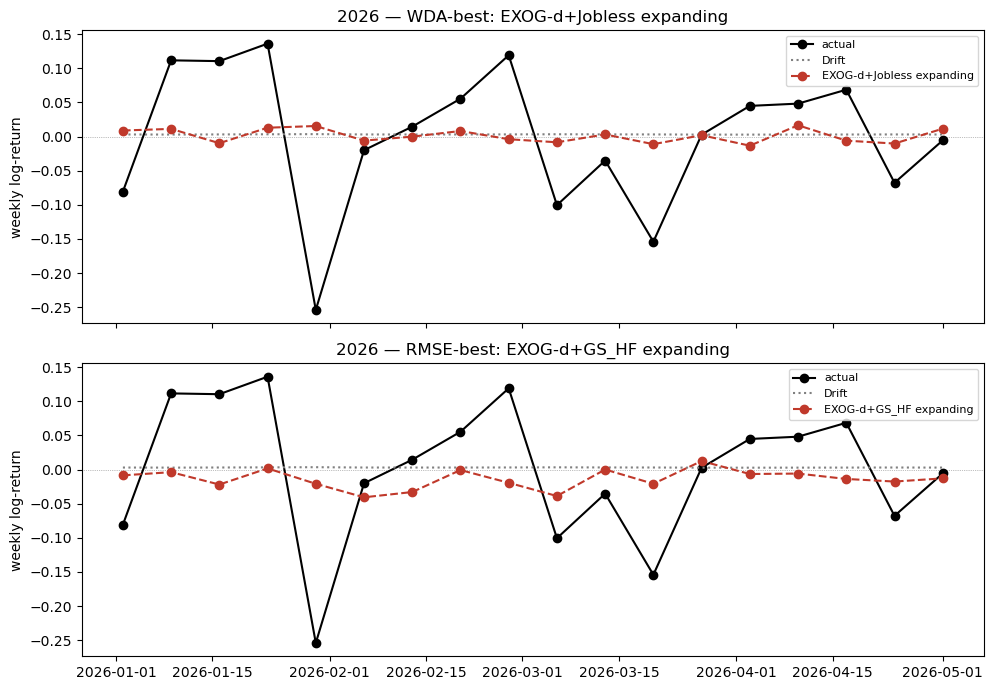

In [20]:
m26 = dates_te >= pd.Timestamp('2026-01-01')
if m26.any():
    drift_p = all_preds['Drift (prevailing mean)']
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    for ax, (tag, bn) in zip(axes, [('WDA', best_wda), ('RMSE', best_rmse)]):
        bp = np.asarray(all_preds[bn])
        ax.axhline(0, color='grey', ls=':', lw=.5)
        ax.plot(dates_te[m26], np.asarray(y_te)[m26], 'k-o', label='actual')
        ax.plot(dates_te[m26], np.asarray(drift_p)[m26], ':', color='grey', label='Drift')
        ax.plot(dates_te[m26], bp[m26], '--o', color='#c0392b', label=bn)
        ax.set_title(f'2026 — {tag}-best: {bn}'); ax.set_ylabel('weekly log-return'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
else:
    print('No 2026 data in test set yet.')


## 13. MIDAS lag-weight profiles

Interpretability comes after the forecast evaluation, mirroring the ARIMA coefficient and VAR diagnostic sections. The plot uses the **best restricted macro-containing variant by RMSE**: this keeps the selection metric aligned with the Drift-floor magnitude test, while still showing both daily/HF and monthly MIDAS weight curves. `Macro_UMIDAS` variants are excluded here because their monthly lags enter as ordinary OLS columns, so they do not have monthly MIDAS weight profiles.


Lag-weight inspection variant: EXOG-d+Macro+GS_HF+FRED_HF expanding  |  fitted with 575 rows


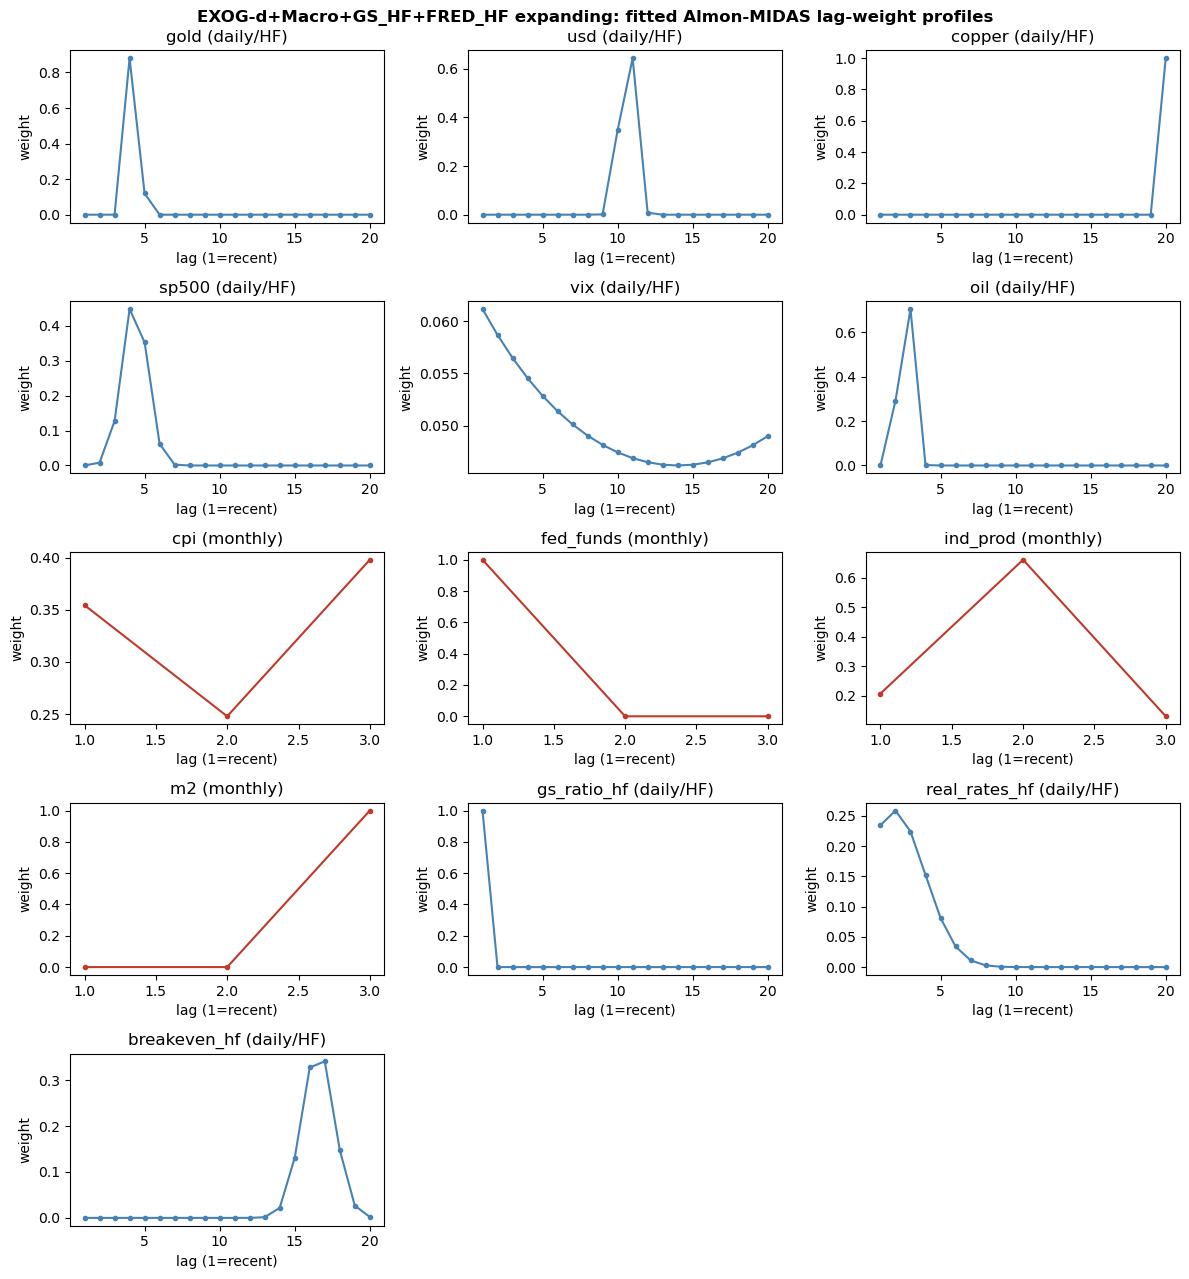

In [21]:
restricted_macro = cand[
    cand['model'].str.contains('+Macro', regex=False)
    & ~cand['model'].str.contains('Macro_UMIDAS', regex=False)
    & cand['model'].str.endswith(' expanding')  # the refit below is expanding-window
]
if restricted_macro.empty:
    raise ValueError('No restricted macro-containing MIDAS variant found for lag-weight inspection.')

lag_weight_variant = restricted_macro.loc[restricted_macro['rmse'].idxmin(), 'model']
lag_cfg = variant_configs[lag_weight_variant]
L = test_pos[-1] + 1
base_L = lag_cfg['baseX'][:L]
mats_L = {name: mat[:L] for name, mat in lag_cfg['mlist'].items()}
fit_rows = finite_rows(y_F[:L], base_L, mats_L)
fit_lag_weights = fit_restricted(
    y_F[:L][fit_rows],
    base_L[fit_rows],
    {name: mat[fit_rows] for name, mat in mats_L.items()},
)

print(f'Lag-weight inspection variant: {lag_weight_variant}  |  fitted with {int(fit_rows.sum())} rows')
ws = fit_lag_weights['weights']
vs = list(ws)
ncol = 3
nrow = int(np.ceil(len(vs) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 2.6 * nrow))
axes = np.atleast_1d(axes).ravel()
for ax, v in zip(axes, vs):
    w = ws[v]
    is_daily = len(w) > N_MACRO_LAGS
    col = 'steelblue' if is_daily else '#c0392b'
    freq = 'daily/HF' if is_daily else 'monthly'
    ax.plot(range(1, len(w) + 1), w, '-o', ms=3, color=col)
    ax.set_title(f'{v} ({freq})')
    ax.set_xlabel('lag (1=recent)')
    ax.set_ylabel('weight')
for ax in axes[len(vs):]:
    ax.axis('off')
fig.suptitle(f'{lag_weight_variant}: fitted {best_spec} lag-weight profiles', fontweight='bold')
plt.tight_layout()
plt.show()
